In [9]:
# Cell 1 — setup
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import pickle
import torch
import matplotlib.pyplot as plt
from kan import KAN
from src.data_loader import fetch_data, compute_features
from sklearn.preprocessing import StandardScaler

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
# Cell 2 — reload and reprocess data (same as notebook 3)
prices = fetch_data()
features = compute_features(prices)

lower = np.percentile(features.values, 1, axis=0)
upper = np.percentile(features.values, 99, axis=0)
clipped = np.clip(features.values, lower, upper)

scaler = StandardScaler()
X = scaler.fit_transform(clipped)

print(f"Features: {X.shape}")

[*********************100%***********************]  4 of 4 completed

Features: (3753, 16)


In [11]:
# Cell 3 — load the HMM and get regime labels
with open("../models/hmm_regime_detector.pkl", "rb") as f:
    hmm = pickle.load(f)

regime_labels = hmm.predict(X)
print("Regime labels loaded.")

Regime labels loaded.


In [12]:
# Cell 4 — load the trained KAN models
input_dim = X.shape[1]
kan_models = {}

for regime in range(3):
    model = KAN(width=[input_dim, 4, 1], grid=5, k=3, seed=42, save_act=True)
    model.load_state_dict(torch.load(f"../models/kan_regime_{regime}.pt"))
    model.eval()
    kan_models[regime] = model

print("KAN models loaded.")

checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
KAN models loaded.


In [13]:
# Cell 5 — walk-forward validation
# We split the data into a rolling training window and a test window.
# The model is retrained from scratch at each step using only past data.
# This is the honest way to evaluate a time series strategy.

from hmmlearn.hmm import GaussianHMM

TRAIN_YEARS = 4    # how many years to train on initially
TEST_YEARS  = 1    # how many years to test on before retraining

days_per_year  = 252
train_size     = TRAIN_YEARS * days_per_year
test_size      = TEST_YEARS  * days_per_year

all_signals = []
all_returns = []
all_dates   = []

spy_returns_full = prices["SPY"].pct_change().dropna()
spy_returns_full = spy_returns_full.reindex(features.index)

n_windows = (len(X) - train_size) // test_size
print(f"Running {n_windows} walk-forward windows...")
print(f"Each window: train on {TRAIN_YEARS} years, test on {TEST_YEARS} year\n")

for window in range(n_windows):
    train_start = window * test_size
    train_end   = train_start + train_size
    test_start  = train_end
    test_end    = min(test_start + test_size, len(X) - 1)

    if test_end <= test_start:
        break

    # Slice out train and test data
    X_train = X[train_start:train_end]
    X_test  = X[test_start:test_end]

    # Fit HMM on training data only
    hmm_wf = GaussianHMM(n_components=3, covariance_type="full",
                          n_iter=100, random_state=42)
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        hmm_wf.fit(X_train)

    # Get regime labels for train and test
    train_regimes = hmm_wf.predict(X_train)
    test_regimes  = hmm_wf.predict(X_test)

    # Train one KAN per regime on training data only
    window_kans = {}
    spy_ret_train = spy_returns_full.values[train_start:train_end]

    for regime in range(3):
        mask = train_regimes == regime
        if mask.sum() < 30:
            # Not enough data for this regime in this window — skip
            window_kans[regime] = None
            continue

        X_r = torch.tensor(X_train[mask], dtype=torch.float32)
        # Target: next day return (shift by 1)
        y_r = spy_ret_train[mask]
        # Trim to same length to handle edge
        min_r = min(len(X_r), len(y_r))
        X_r = X_r[:min_r]
        y_r = torch.tensor(y_r[:min_r], dtype=torch.float32).unsqueeze(1)

        model = KAN(width=[input_dim, 4, 1], grid=5, k=3,
                    seed=42, save_act=True)
        model.speed()
        dataset = {"train_input": X_r, "train_label": y_r,
                   "test_input":  X_r, "test_label":  y_r}
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model.fit(dataset, opt="LBFGS", steps=30, lamb=0.01, log=30)
        model.eval()
        window_kans[regime] = model

    # Generate signals on TEST data only (never seen during training)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

    for i in range(len(X_test) - 1):
        regime = test_regimes[i]
        kan = window_kans.get(regime)

        if kan is None:
            signal = 0.0   # no model for this regime, stay in cash
        else:
            with torch.no_grad():
                pred = kan(X_test_tensor[i].unsqueeze(0)).item()
            signal = 1.0 if pred > 0 else 0.0

        actual_return = spy_returns_full.values[test_start + i + 1]
        all_signals.append(signal)
        all_returns.append(actual_return)
        all_dates.append(features.index[test_start + i + 1])

    print(f"  Window {window+1}/{n_windows} done — "
          f"test period: {features.index[test_start].date()} "
          f"to {features.index[test_end].date()}")

print(f"\nTotal out-of-sample days: {len(all_signals)}")

Running 10 walk-forward windows...
Each window: train on 4 years, test on 1 year

checkpoint directory created: ./model
saving model version 0.0
setting lamb=0. If you want to set lamb > 0, set self.save_act=True


| train_loss: 5.08e-03 | test_loss: 5.08e-03 | reg: 0.00e+00 | : 100%|█| 30/30 [00:01<00:00, 24.86it


checkpoint directory created: ./model
saving model version 0.0
setting lamb=0. If you want to set lamb > 0, set self.save_act=True


| train_loss: 6.51e-03 | test_loss: 6.51e-03 | reg: 0.00e+00 | : 100%|█| 30/30 [00:00<00:00, 33.97it


checkpoint directory created: ./model
saving model version 0.0
setting lamb=0. If you want to set lamb > 0, set self.save_act=True


...

checkpoint directory created: ./model
saving model version 0.0
setting lamb=0. If you want to set lamb > 0, set self.save_act=True


| train_loss: 4.43e-03 | test_loss: 4.43e-03 | reg: 0.00e+00 | : 100%|█| 30/30 [00:01<00:00, 23.43it


checkpoint directory created: ./model
saving model version 0.0
setting lamb=0. If you want to set lamb > 0, set self.save_act=True


| train_loss: 1.01e-02 | test_loss: 1.01e-02 | reg: 0.00e+00 | : 100%|█| 30/30 [00:01<00:00, 21.99it


  Window 10/10 done — test period: 2023-02-07 to 2024-02-08

Total out-of-sample days: 2510


In [14]:
# Cell 6 — compute honest out-of-sample metrics
strat = pd.Series(all_returns) * pd.Series(all_signals)
bh    = pd.Series(all_returns)
dates = pd.DatetimeIndex(all_dates)

print("=" * 45)
print(f"{'Metric':<25} {'KAN Strategy':>10} {'Buy & Hold':>10}")
print("=" * 45)
print(f"{'Sharpe Ratio':<25} {sharpe(strat):>10.3f} {sharpe(bh):>10.3f}")
print(f"{'Annualized Return':<25} {annualized_return(strat)*100:>9.1f}% {annualized_return(bh)*100:>9.1f}%")
print(f"{'Max Drawdown':<25} {max_drawdown(strat)*100:>9.1f}% {max_drawdown(bh)*100:>9.1f}%")
print(f"{'Daily Vol (ann.)':<25} {strat.std()*np.sqrt(252)*100:>9.1f}% {bh.std()*np.sqrt(252)*100:>9.1f}%")
print("=" * 45)
print("\n* All results are fully out-of-sample (walk-forward validation)")

Metric                    KAN Strategy Buy & Hold
Sharpe Ratio                   0.384      0.800
Annualized Return               3.9%      13.2%
Max Drawdown                  -28.3%     -33.7%
Daily Vol (ann.)               11.8%      17.5%

* All results are fully out-of-sample (walk-forward validation)


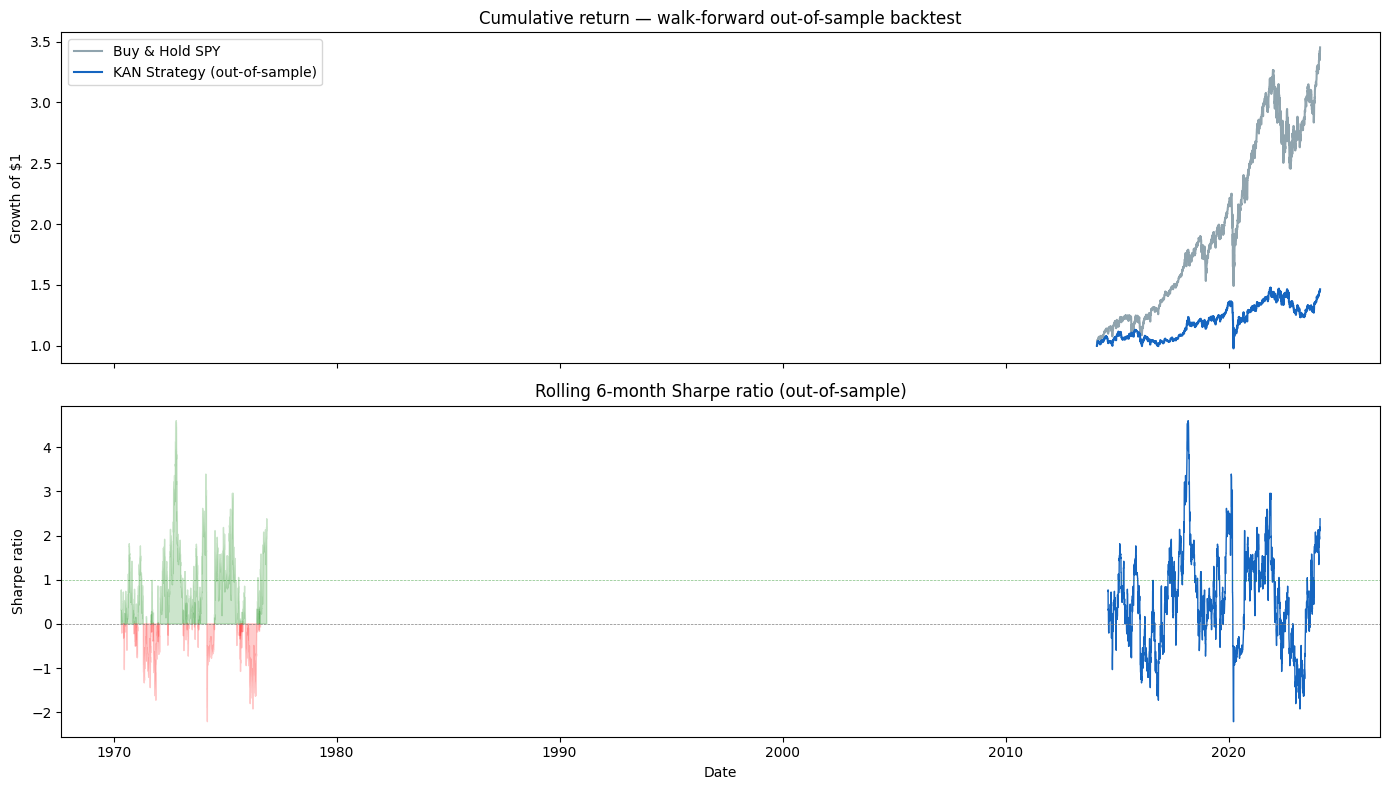

In [15]:
# Cell 7 — equity curve (reuse your existing plot code, just update variable names)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

cumulative_strat = (1 + strat).cumprod()
cumulative_bh    = (1 + bh).cumprod()

axes[0].plot(dates, cumulative_bh.values,
             label="Buy & Hold SPY", color="#90A4AE", linewidth=1.5)
axes[0].plot(dates, cumulative_strat.values,
             label="KAN Strategy (out-of-sample)", color="#1565C0", linewidth=1.5)
axes[0].set_title("Cumulative return — walk-forward out-of-sample backtest")
axes[0].set_ylabel("Growth of $1")
axes[0].legend()

window = 126
rolling_sharpe = strat.rolling(window).apply(sharpe)

axes[1].plot(dates, rolling_sharpe.values, color="#1565C0", linewidth=1)
axes[1].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[1].axhline(1, color="green", linewidth=0.5, linestyle="--", alpha=0.5)
axes[1].fill_between(range(len(rolling_sharpe)), rolling_sharpe.values, 0,
                     where=rolling_sharpe.values > 0, alpha=0.2, color="green")
axes[1].fill_between(range(len(rolling_sharpe)), rolling_sharpe.values, 0,
                     where=rolling_sharpe.values < 0, alpha=0.2, color="red")
axes[1].set_title("Rolling 6-month Sharpe ratio (out-of-sample)")
axes[1].set_ylabel("Sharpe ratio")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.savefig("../outputs/equity_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# Cell 8 — performance breakdown by regime
strat_series = pd.Series(all_signals) * pd.Series(all_returns)
regime_series = pd.Series([hmm.predict(X[i:i+1])[0] 
                           for i in range(len(all_signals))])

print("Performance by regime:")
print("=" * 50)
for r in range(3):
    mask = regime_series == r
    r_strat = strat_series[mask]
    r_bh    = pd.Series(all_returns)[mask]
    days    = mask.sum()
    print(f"\nRegime {r} ({days} days, {days/len(regime_series)*100:.0f}% of time):")
    print(f"  KAN Sharpe:      {sharpe(r_strat):.3f}")
    print(f"  B&H Sharpe:      {sharpe(r_bh):.3f}")
    print(f"  % days long:     {pd.Series(all_signals)[mask].mean()*100:.0f}%")

Performance by regime:

Regime 0 (0 days, 0% of time):
  KAN Sharpe:      nan
  B&H Sharpe:      nan
  % days long:     nan%

Regime 1 (2510 days, 100% of time):
  KAN Sharpe:      0.384
  B&H Sharpe:      0.800
  % days long:     56%

Regime 2 (0 days, 0% of time):
  KAN Sharpe:      nan
  B&H Sharpe:      nan
  % days long:     nan%
